In [1]:
# Data Cleaning

import pandas as pd
df = pd.read_csv(r"C:\Users\Mikhil Baby\Downloads\archive (2)\retail_sales_dataset.csv")

In [2]:
df.head(6)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30


In [4]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [5]:
list(df.columns)

['Transaction ID',
 'Date',
 'Customer ID',
 'Gender',
 'Age',
 'Product Category',
 'Quantity',
 'Price per Unit',
 'Total Amount']

In [6]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [7]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [8]:
# Standardizing Columns
df.columns = (
    df.columns
    .str.lower()
    .str.replace(r"[\s,\-]+", "_", regex=True)
    .str.replace(r"[^\w]", "", regex=True)
)

In [9]:
print(f"Standardized Columns {df.columns.tolist()}\n") 


Standardized Columns ['transaction_id', 'date', 'customer_id', 'gender', 'age', 'product_category', 'quantity', 'price_per_unit', 'total_amount']



In [10]:
# Null values
df.isnull().sum()

transaction_id      0
date                0
customer_id         0
gender              0
age                 0
product_category    0
quantity            0
price_per_unit      0
total_amount        0
dtype: int64

In [11]:
# Finding Duplicate Values
dupes=df.duplicated().sum()
print(dupes)


0


In [12]:
df['age'].head()

0    34
1    26
2    50
3    37
4    30
Name: age, dtype: int64

In [13]:
labels=["Young-adult","Adult","Middle-aged","Senior"]
df['age_group']=pd.qcut(df['age'],q=4,labels=labels)
df[["age","age_group"]].head(10)

,age,age_group
0,34,Adult
1,26,Young-adult
2,50,Middle-aged
3,37,Adult
4,30,Adult
5,45,Middle-aged
6,46,Middle-aged
7,30,Adult
8,63,Senior
9,52,Middle-aged


In [14]:
df[["total_amount","age_group"]].head(10)

,total_amount,age_group
0,150,Adult
1,1000,Young-adult
2,30,Middle-aged
3,500,Adult
4,100,Adult
5,30,Middle-aged
6,50,Middle-aged
7,100,Adult
8,600,Senior
9,200,Middle-aged


In [15]:
df.head(6)

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,age_group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,Adult
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,Young-adult
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,Middle-aged
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,Adult
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,Adult
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30,Middle-aged


In [16]:
df=df.drop("age_group",axis=1)

In [17]:
df.head(6)

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30


In [18]:
import sys
print(sys.executable)

c:\Users\Mikhil Baby\OneDrive\Day1\.venv\Scripts\python.exe


In [19]:
!pip install seaborn --trusted-host pypi.org --trusted-host files.pythonhosted.org


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Data Visualisation

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Identifying Outliers


<Axes: xlabel='price_per_unit'>

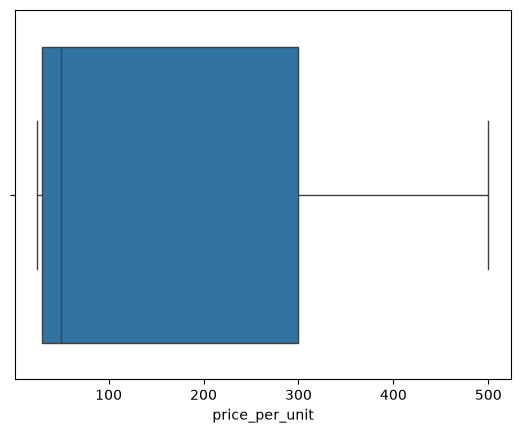

In [21]:
sns.boxplot(data=df,x='price_per_unit')

In [22]:
df[df['price_per_unit']==500]

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
12,13,2023-08-05,CUST013,Male,22,Electronics,3,500,1500
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
15,16,2023-02-17,CUST016,Male,19,Clothing,3,500,1500
...,...,...,...,...,...,...,...,...,...
969,970,2023-05-16,CUST970,Male,59,Electronics,4,500,2000
983,984,2023-08-29,CUST984,Male,56,Clothing,1,500,500
985,986,2023-01-17,CUST986,Female,49,Clothing,2,500,1000
989,990,2023-05-25,CUST990,Female,58,Beauty,2,500,1000


In [23]:
df['price_per_unit'].skew()

np.float64(0.7363077780665441)

In [24]:
df['price_per_unit'].describe()

count    1000.000000
mean      179.890000
std       189.681356
min        25.000000
25%        30.000000
50%        50.000000
75%       300.000000
max       500.000000
Name: price_per_unit, dtype: float64

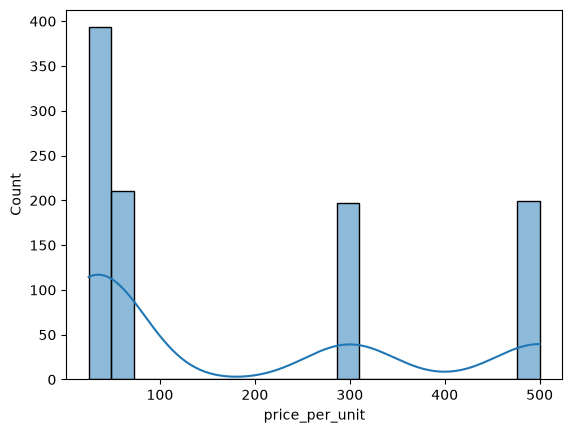

In [25]:
sns.histplot(df['price_per_unit'], bins=20,kde=True)
plt.show()

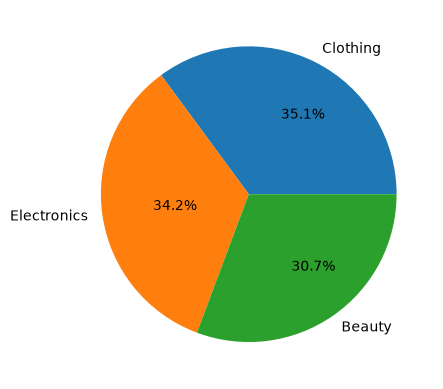

In [26]:
category_counts = df['product_category'].value_counts()

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%11.1f%%'
)
plt.show()

# **Analysis Total revenue generation based on product category**

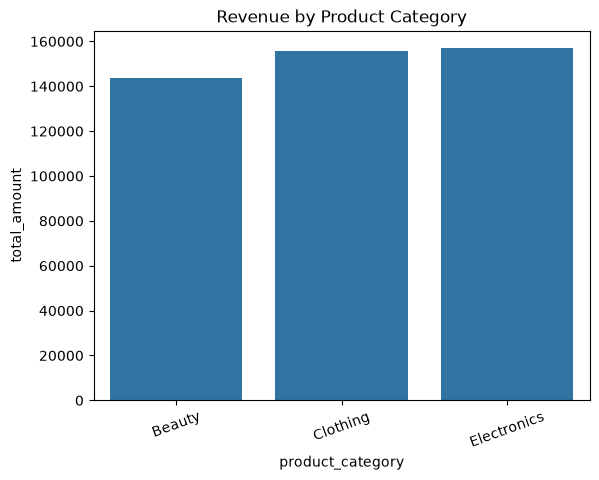

In [42]:

category_revenue = df.groupby('product_category')['total_amount'].sum().reset_index()

sns.barplot(
    data=category_revenue,
    x='product_category',
    y='total_amount'
)

plt.xticks(rotation=20)
plt.title('Revenue by Product Category')
plt.show()

# **Time Series Analysis in Sales**

In [35]:
df['date'] = pd.to_datetime(df['date'])

monthly_revenue = (
    df.groupby(df['date'].dt.to_period('M'))['total_amount']
      .sum()
      .reset_index()
)

monthly_revenue['date'] = monthly_revenue['date'].astype(str)

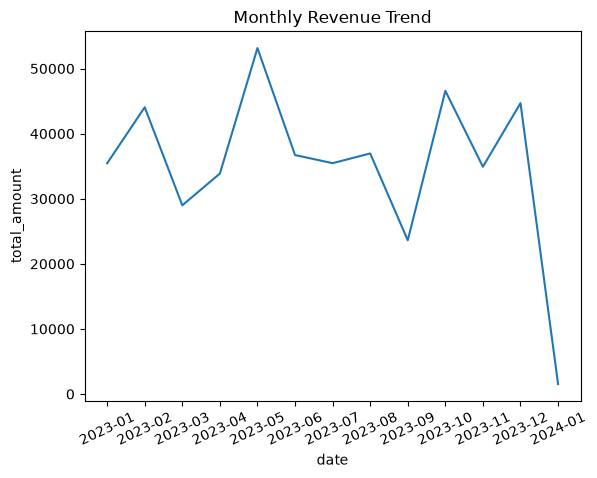

In [36]:
sns.lineplot(
    data=monthly_revenue,
    x='date',
    y='total_amount'
)

plt.xticks(rotation=25)
plt.title('Monthly Revenue Trend')
plt.show()

In [31]:
df.head(10)

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


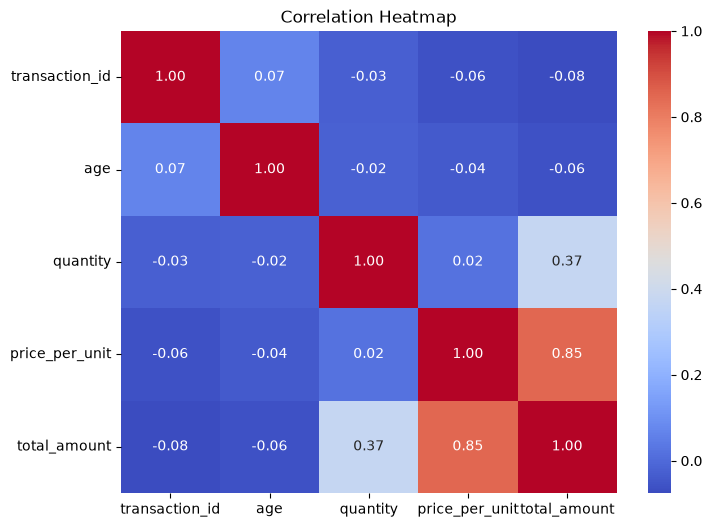

In [39]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

# **Analysing quantity sold over month for each category**

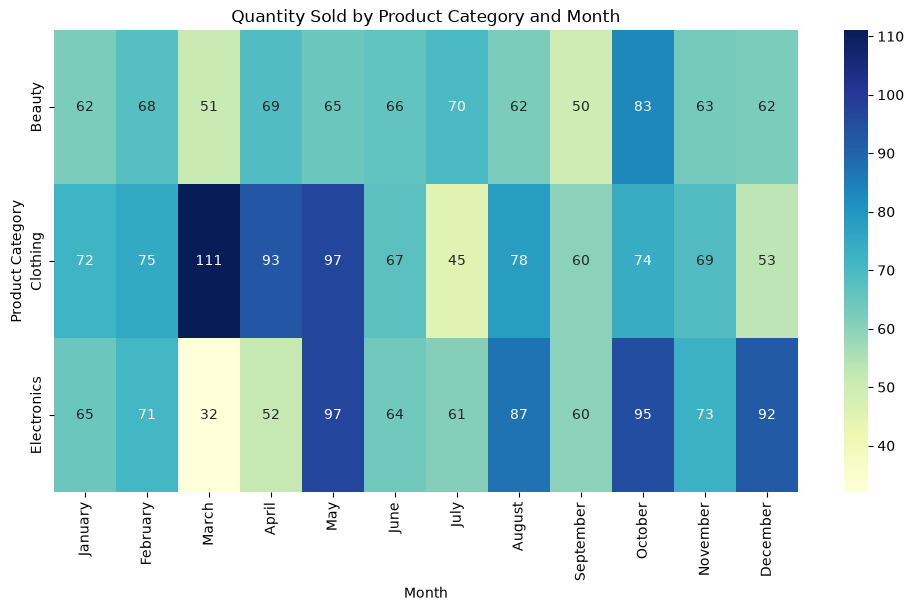

In [43]:
df['Month'] = df['date'].dt.month_name()

# Pivot table
pivot = df.pivot_table(
    values='quantity',
    index='product_category',
    columns='Month',
    aggfunc='sum'
)

# Arrange months in order
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

pivot = pivot.reindex(columns=month_order)

# Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt='.0f')

plt.title("Quantity Sold by Product Category and Month")
plt.xlabel("Month")
plt.ylabel("Product Category")
plt.show()